# Feature Engineering

In this tutorial you will learn to:
- Create **new features** from existing ones using domain reasoning
- Apply **binning** to convert a continuous feature into groups
- Build **polynomial features** with sklearn
- Recognize what makes a **good feature** vs. a harmful one

We'll work with a **used-car sales** dataset — over 3,500 listings with a car's age, kilometres driven, and selling price.

> **Key insight**: A linear model can only combine inputs linearly. If the true relationship between a feature and the target curves, the model can't capture it — unless you build that non-linearity in explicitly as a new feature. Feature engineering is how you give the model the information it needs, in a form it can use.

> **Data source:** *Car Details from CarDekho* — used-car listings (specifications and asking prices) from CarDekho.com, published on Kaggle (e.g., the *Car Details Dataset* by Akshay Dattatray Khare).

---
## Theory: What Is Feature Engineering?

**Feature engineering** is the process of creating new input features from existing ones — using arithmetic, domain knowledge, or patterns you spotted in EDA.

A classic example: you have `length` and `width` as separate features. A linear model can weight each one, but it cannot multiply them. If what actually matters is the area, you have to create `area = length * width` as an explicit feature.

The same idea covers:
- Ratios (`KM_Driven / car_age` for kilometres driven per year)
- Differences (`current_score - previous_score` for improvement)
- Binned groups (`age_group` from a continuous age column)
- Polynomial terms (`car_age²` when the relationship with price curves)

Feature engineering is one of the highest-leverage activities in ML — often more impactful than changing the algorithm.

---
## Step 1: Setup and Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

plt.rcParams['figure.figsize'] = (10, 4)
sns.set_style('whitegrid')

RANDOM_SEED = 23
np.random.seed(RANDOM_SEED)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [2]:
df = pd.read_csv('car_price.csv')
df = df.drop_duplicates().reset_index(drop=True)

# Derive car age from the manufacturing year. The newest models in the data are 2020, so we
# measure age relative to 2021 (newest year + 1). Deriving the reference from the data keeps
# every number reproducible no matter when you run this.
REFERENCE_YEAR = df['Year'].max() + 1
df['car_age'] = REFERENCE_YEAR - df['Year']

print(f'Shape: {df.shape}   |   reference year: {REFERENCE_YEAR}')
df[['Year', 'car_age', 'KM_Driven', 'Selling_Price']].head()

Shape: (3577, 10)   |   reference year: 2021


,Year,car_age,KM_Driven,Selling_Price
0,2007,14,70000,60000
1,2007,14,50000,135000
2,2012,9,100000,600000
3,2017,4,46000,250000
4,2014,7,141000,450000


In [8]:
# We engineer from the two numerical features; the target is the (log) selling price.
# Categorical columns (Fuel, Transmission, Owner, ...) need encoding before a model can
# use them; here we focus on engineering numerical features.
numerical_features = ['car_age', 'KM_Driven']
target = 'Selling_Price'

X = df[numerical_features].copy()
y = np.log1p(df[target].values)   # log-transform the right-skewed target
print(f"target values: {y}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# Clip KM_Driven outliers: threshold from TRAINING data only, then apply to all splits
km_p99 = X_train['KM_Driven'].quantile(0.99)
X_train['KM_Driven'] = X_train['KM_Driven'].clip(upper=km_p99)
X_test['KM_Driven'] = X_test['KM_Driven'].clip(upper=km_p99)
df['KM_Driven'] = df['KM_Driven'].clip(upper=km_p99)   # keep df consistent for later cells

# Baseline: no feature engineering, just the two raw numerical features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f"km_p99: {km_p99}")

model = LinearRegression()
model.fit(X_train_s, y_train)
baseline_rmse = rmse(y_test, model.predict(X_test_s))
print(f'Baseline RMSE (log scale, 2 features): {baseline_rmse:.4f}')

results = {'Baseline (car_age, KM_Driven)': baseline_rmse}

target values: [11.00211651 11.81303746 13.3046866  ... 11.60824474 13.67048594
 12.32386013]
km_p99: 224984.91200000021
Baseline RMSE (log scale, 2 features): 0.5718


> **Note**: We keep RMSE in log scale throughout this tutorial so the numbers stay comparable (RMSE on a log target is exactly the RMSLE metric the House Prices competition uses). Better-engineered features should bring it down.

---
## Step 2: Creating New Features from Domain Knowledge

Feature engineering starts with a question: **what do I know about this domain that might help the model?**

For used-car prices:
- A car driven 120,000 km over 12 years (10,000 km/year) sees gentler use than the same 120,000 km over 4 years. The *rate* — kilometres per year — may matter more than the raw total.
- Cars depreciate fast in their early years and then level off, so the effect of age on price is non-linear.
- Age and mileage interact: an old car that is *also* high-mileage may be worth disproportionately less.

Let's turn these intuitions into features.

In [5]:
df_eng = df[numerical_features + [target]].copy()

# Feature 1: kilometres driven per year (a usage-intensity ratio)
df_eng['km_per_year'] = df_eng['KM_Driven'] / df_eng['car_age']

print(df_eng[['car_age', 'KM_Driven', 'km_per_year']].head())
print(f"\nMedian km/year: {df_eng['km_per_year'].median():,.0f}")

   car_age  KM_Driven   km_per_year
0       14    70000.0   5000.000000
1       14    50000.0   3571.428571
2        9   100000.0  11111.111111
3        4    46000.0  11500.000000
4        7   141000.0  20142.857143

Median km/year: 8,040


In [6]:
# Feature 2: age x mileage interaction (old AND heavily driven = compounded wear)
df_eng['age_x_km'] = df_eng['car_age'] * df_eng['KM_Driven']

# Feature 3: car_age squared (captures non-linear depreciation)
df_eng['car_age_sq'] = df_eng['car_age'] ** 2

print(df_eng[['car_age', 'KM_Driven', 'km_per_year', 'age_x_km', 'car_age_sq']].head())

   car_age  KM_Driven   km_per_year  age_x_km  car_age_sq
0       14    70000.0   5000.000000  980000.0         196
1       14    50000.0   3571.428571  700000.0         196
2        9   100000.0  11111.111111  900000.0          81
3        4    46000.0  11500.000000  184000.0          16
4        7   141000.0  20142.857143  987000.0          49


In [9]:
features_v2 = ['car_age', 'KM_Driven', 'km_per_year', 'age_x_km', 'car_age_sq']

X2 = df_eng[features_v2].copy()
y2 = np.log1p(df_eng[target].values)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=RANDOM_SEED)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

model.fit(X2_train_s, y2_train)
rmse_v2 = rmse(y2_test, model.predict(X2_test_s))
results['+ km_per_year, age_x_km, car_age_sq'] = rmse_v2

direction = 'improved' if rmse_v2 < baseline_rmse else 'got worse'
print(f'RMSE with engineered features: {rmse_v2:.4f}')
print(f'Baseline:                      {baseline_rmse:.4f}')
print(f'Change: {rmse_v2 - baseline_rmse:+.4f}  ({direction})')

RMSE with engineered features: 0.5626
Baseline:                      0.5718
Change: -0.0092  (improved)


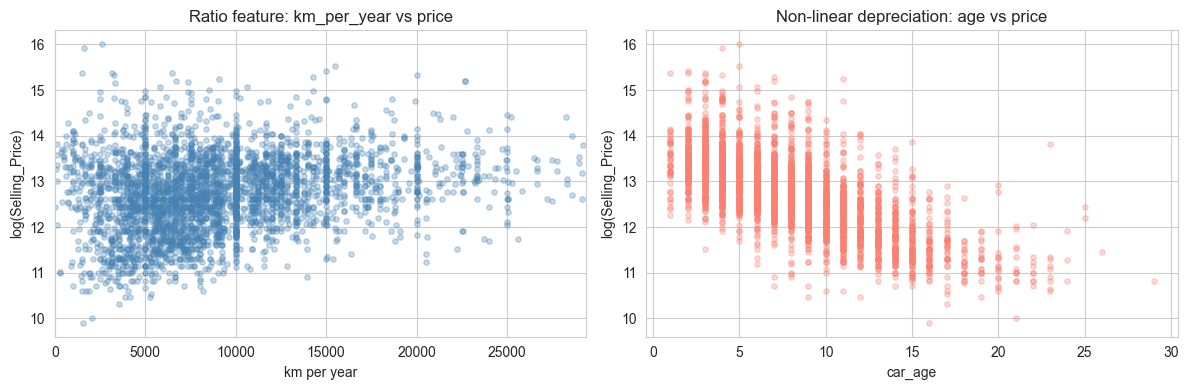

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_eng['km_per_year'], np.log1p(df_eng[target]), alpha=0.3, s=15, color='steelblue')
axes[0].set_xlabel('km per year')
axes[0].set_ylabel('log(Selling_Price)')
axes[0].set_title('Ratio feature: km_per_year vs price')
axes[0].set_xlim(0, df_eng['km_per_year'].quantile(0.99))

axes[1].scatter(df_eng['car_age'], np.log1p(df_eng[target]), alpha=0.3, s=15, color='salmon')
axes[1].set_xlabel('car_age')
axes[1].set_ylabel('log(Selling_Price)')
axes[1].set_title('Non-linear depreciation: age vs price')

plt.tight_layout()
plt.show()

---
## Step 3: Binning

**Binning** (also called bucketing) converts a continuous feature into discrete groups. It is useful when:
- The relationship between the feature and the target is step-like rather than gradual
- You want to capture a threshold effect (e.g., the jump from "nearly new" to "used")
- The feature has outliers you would rather group than clip

Two strategies:
- **Equal-width bins**: each bin spans the same value range
- **Quantile bins**: each bin holds the same number of samples

In [11]:
# Equal-width bins: split the car_age range into labelled groups
df_eng['age_group_equal'] = pd.cut(
    df_eng['car_age'],
    bins=[0, 3, 7, 12, 100],
    labels=['0-3 (newish)', '4-7', '8-12', '13+ (old)']
)

# Quantile bins: equal number of cars in each group
df_eng['age_group_quantile'] = pd.qcut(df_eng['car_age'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

print('Equal-width age groups:')
print(df_eng['age_group_equal'].value_counts().sort_index())
print('\nQuantile age groups (equal count):')
print(df_eng['age_group_quantile'].value_counts().sort_index())

Equal-width age groups:
age_group_equal
0-3 (newish)     502
4-7             1282
8-12            1262
13+ (old)        531
Name: count, dtype: int64

Quantile age groups (equal count):
age_group_quantile
Q1    1131
Q2     951
Q3     795
Q4     700
Name: count, dtype: int64


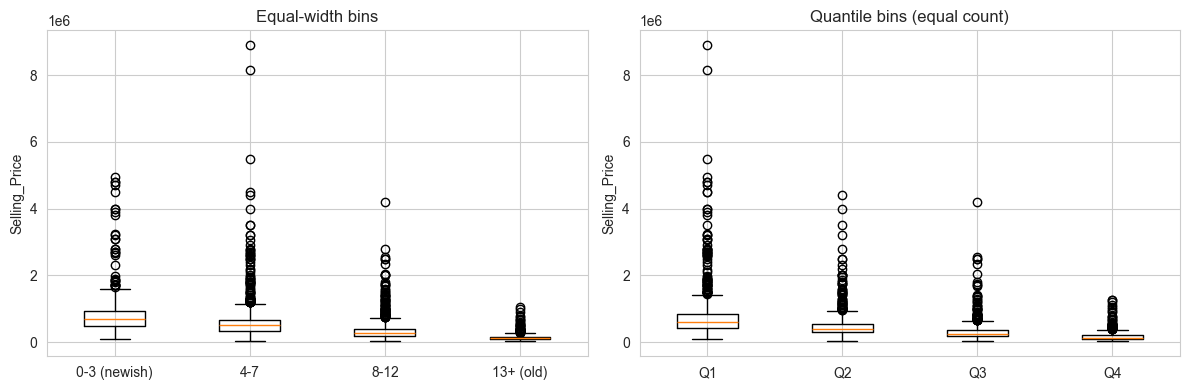

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cols = ['age_group_equal', 'age_group_quantile']
titles = ['Equal-width bins', 'Quantile bins (equal count)']

for ax, col, title in zip(axes, cols, titles):
    if hasattr(df_eng[col], 'cat'):
        cats = list(df_eng[col].cat.categories)
    else:
        cats = sorted(df_eng[col].dropna().unique())
    groups = [df_eng.loc[df_eng[col] == c, target].values for c in cats]
    ax.boxplot(groups, tick_labels=[str(c) for c in cats])
    ax.set_ylabel('Selling_Price')
    ax.set_title(title)
plt.tight_layout()
plt.show()

# I've built these charts to show the average selling price for each age group. The idea is to check outliers and see if the average price is consistent across the groups.

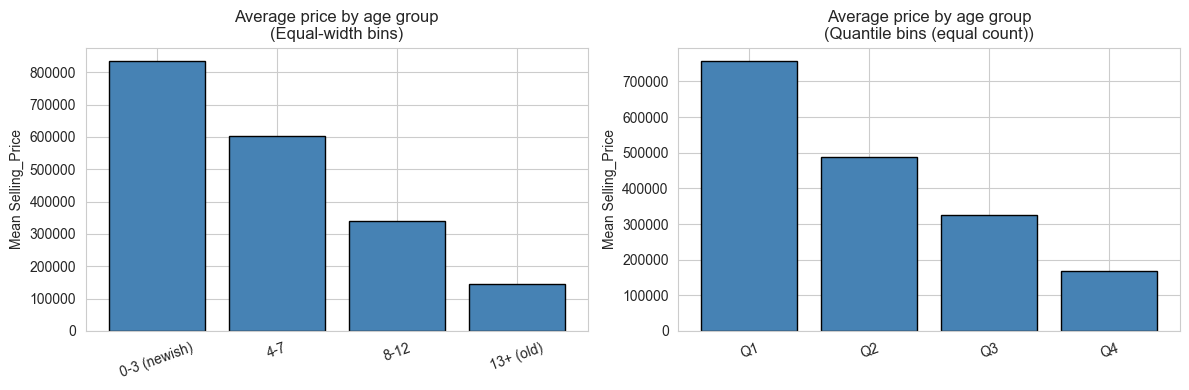

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(
    axes,
    ['age_group_equal', 'age_group_quantile'],
    ['Equal-width bins', 'Quantile bins (equal count)']
):
    group_means = df_eng.groupby(col, observed=True)[target].mean().sort_index()
    ax.bar(range(len(group_means)), group_means.values, color='steelblue', edgecolor='black')
    ax.set_xticks(range(len(group_means)))
    ax.set_xticklabels(group_means.index, rotation=20)
    ax.set_ylabel('Mean Selling_Price')
    ax.set_title(f'Average price by age group\n({title})')

plt.tight_layout()
plt.show()

In [17]:
# To use a binned feature in a model, convert the groups to numbers.
# Age groups have a natural order (newer -> older), so ordinal numbering is appropriate.
age_order = {'0-3 (newish)': 0, '4-7': 1, '8-12': 2, '13+ (old)': 3}
df_eng['age_group_num'] = df_eng['age_group_equal'].map(age_order)

print(df_eng[['car_age', 'age_group_equal', 'age_group_num']].head(8))

   car_age age_group_equal age_group_num
0       14       13+ (old)             3
1       14       13+ (old)             3
2        9            8-12             2
3        4             4-7             1
4        7             4-7             1
5       14       13+ (old)             3
6        5             4-7             1
7        7             4-7             1


> **Note**: We won't add `age_group_num` to the RMSE comparison — it encodes the same information as the continuous `car_age` already in the model, just more coarsely. Binning earns its place when there is a domain-meaningful threshold (a legal age, a warranty cut-off), not when you are simply discretizing a feature you already have in full.

---
## Step 4: Polynomial Features

Polynomial features systematically generate combinations of features up to a given degree. For two features `x₁` and `x₂`, degree=2 produces `x₁, x₂, x₁², x₁·x₂, x₂²` — the originals plus their squares and pairwise product.

This lets a linear model fit curved relationships without switching to a non-linear algorithm — a natural fit for car prices, which fall non-linearly with age and mileage.

In [24]:
df_poly = df[numerical_features].copy()
df_poly['car_age_sq'] = df_poly['car_age'] ** 2
df_poly['km_sq'] = df_poly['KM_Driven'] ** 2
df_poly['age_times_km'] = df_poly['car_age'] * df_poly['KM_Driven']

print('Manual polynomial features:')
df_poly.head()

Manual polynomial features:


,car_age,KM_Driven,car_age_sq,km_sq,age_times_km
0,14,70000.0,196,4.900000e+09,980000.0
1,14,50000.0,196,2.500000e+09,700000.0
2,9,100000.0,81,1.000000e+10,900000.0
3,4,46000.0,16,2.116000e+09,184000.0
4,7,141000.0,49,1.988100e+10,987000.0


In [25]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[numerical_features])

print(f'Original features: {len(numerical_features)}')
print(f'After degree=2 polynomial: {X_poly.shape[1]}')
print(f'\nGenerated feature names:')
print(poly.get_feature_names_out(numerical_features))

Original features: 2
After degree=2 polynomial: 5

Generated feature names:
['car_age' 'KM_Driven' 'car_age^2' 'car_age KM_Driven' 'KM_Driven^2']


In [29]:
y_all = np.log1p(df[target].values)

X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly, y_all, test_size=0.2, random_state=RANDOM_SEED
)

scaler_p = StandardScaler()
X_poly_train_s = scaler_p.fit_transform(X_poly_train)
X_poly_test_s = scaler_p.transform(X_poly_test)

model.fit(X_poly_train_s, y_poly_train)
rmse_poly = rmse(y_poly_test, model.predict(X_poly_test_s))
results['+ polynomial (degree=2)'] = rmse_poly

print(f'Polynomial features (degree=2): {X_poly.shape[1]} features, RMSE = {rmse_poly:.4f}')
print(f'Baseline (2 features):          RMSE = {baseline_rmse:.4f}')
print(f'Change: {rmse_poly - baseline_rmse:+.4f}')

Polynomial features (degree=2): 5 features, RMSE = 0.5682
Baseline (2 features):          RMSE = 0.5718
Change: -0.0037


> **Note on polynomial features and leakage**: `PolynomialFeatures` is purely arithmetic — it squares and multiplies existing values. It doesn't *learn* any statistic from the data, so applying it before the split is safe. Scalers and imputers, by contrast, learn from the data (mean, median, std) and must be fit on training data only.

In [30]:
# Overfitting shows up when a model has many features relative to its training rows.
# With 2 features and thousands of rows we can't overfit no matter the degree, so we
# deliberately train on a SMALL sample (60 cars) and push the polynomial degree up.
X_base = df[numerical_features].values
y_base = np.log1p(df[target].values)
X_tr_full, X_hold, y_tr_full, y_hold = train_test_split(X_base, y_base, test_size=0.3, random_state=RANDOM_SEED)

rng = np.random.RandomState(RANDOM_SEED)
small = rng.choice(len(X_tr_full), size=60, replace=False)
X_small, y_small = X_tr_full[small], y_tr_full[small]

print(f'Training on {len(X_small)} cars, evaluating on {len(X_hold)} held-out cars:\n')
for degree in [2, 4, 8]:
    pf = PolynomialFeatures(degree=degree, include_bias=False)
    X_small_p = pf.fit_transform(X_small)
    X_hold_p = pf.transform(X_hold)

    sc = StandardScaler()
    X_small_ps = sc.fit_transform(X_small_p)
    X_hold_ps = sc.transform(X_hold_p)

    m = LinearRegression().fit(X_small_ps, y_small)
    tr = rmse(y_small, m.predict(X_small_ps))
    te = rmse(y_hold, m.predict(X_hold_ps))
    print(f'  degree={degree}: {X_small_p.shape[1]:2d} features | train RMSE {tr:7.3f} | test RMSE {te:11.3f} | gap {te - tr:+.3f}')

print('\nAs the degree rises, train RMSE falls but test RMSE explodes: the model memorizes the')
print('60 training cars and predicts nonsense for everything else. That widening gap is overfitting.')

Training on 60 cars, evaluating on 1074 held-out cars:

  degree=2:  5 features | train RMSE   0.595 | test RMSE       0.564 | gap -0.031
  degree=4: 14 features | train RMSE   0.557 | test RMSE       1.141 | gap +0.585
  degree=8: 44 features | train RMSE   0.300 | test RMSE    3381.466 | gap +3381.166

As the degree rises, train RMSE falls but test RMSE explodes: the model memorizes the
60 training cars and predicts nonsense for everything else. That widening gap is overfitting.


---
## Step 5: What Makes a Good Feature?

Not every engineered feature is useful. Before adding one, ask:

1. **Is it available at prediction time?** A feature that needs information you only get *after* the outcome is leakage. For a price model that scores a car *when it is listed*, something like `days_on_market_until_sold` is not known yet — using it would inflate your offline score and fail in production.
2. **Does it have a meaningful interpretation?** Artifacts of data collection (row index, database ID) don't generalize.
3. **Is it redundant with something you already have?** A rescaled or duplicated copy of an existing feature — the same mileage in miles and in kilometres, say — carries no new information for a linear model.
4. **Does it help on held-out data?** Always validate a feature on the test set, never the training set.

In [31]:
# A feature that looks new but is redundant: the same mileage in a different unit.
# km_in_miles is just KM_Driven * 0.621 — perfectly correlated, so it adds no new signal.
df_test_feature = df[numerical_features + [target]].copy()
df_test_feature['km_in_miles'] = df_test_feature['KM_Driven'] * 0.621

X_red = df_test_feature[['car_age', 'KM_Driven', 'km_in_miles']].values
y_red = np.log1p(df_test_feature[target].values)

X_rd_train, X_rd_test, y_rd_train, y_rd_test = train_test_split(X_red, y_red, test_size=0.2, random_state=RANDOM_SEED)
scaler_r = StandardScaler()
model.fit(scaler_r.fit_transform(X_rd_train), y_rd_train)
rmse_red = rmse(y_rd_test, model.predict(scaler_r.transform(X_rd_test)))

print(f'Baseline (car_age, KM_Driven):           RMSE = {baseline_rmse:.4f}')
print(f'+ km_in_miles (KM in different units):   RMSE = {rmse_red:.4f}')
print('\nIdentical — a rescaled copy of an existing feature adds no information at all.')

Baseline (car_age, KM_Driven):           RMSE = 0.5718
+ km_in_miles (KM in different units):   RMSE = 0.5718

Identical — a rescaled copy of an existing feature adds no information at all.


---
## Step 6: Summary Comparison

In [32]:
print('RMSE comparison (log scale — lower is better):\n')
for name, r in results.items():
    print(f'  {name:42s}: {r:.4f}')

best = min(results, key=results.get)
print(f'\nBest: {best}')

RMSE comparison (log scale — lower is better):

  Baseline (car_age, KM_Driven)             : 0.5718
  + km_per_year, age_x_km, car_age_sq       : 0.5626
  + polynomial (degree=2)                   : 0.5682

Best: + km_per_year, age_x_km, car_age_sq


> **Note**: With only two raw numerical features, the gains are modest — but notice in the comparison above that the hand-crafted set edged out the automated polynomial set. The difference is the `km_per_year` *ratio*: `PolynomialFeatures` builds squares and products but never a ratio (a division), so domain knowledge still adds something automation can't reach. The real payoff comes on datasets like House Prices, with dozens of features and deep domain signal — the skills (ratios, interactions, polynomial terms, threshold flags) transfer directly.

---
## YOUR TURN

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

**Exercise: Engineer a feature of your own**

Create one new feature you expect to improve the model's ability to predict `Selling_Price`.

Some ideas to consider:
- A `km_per_year` threshold flag (e.g., `high_usage = km_per_year > 15000`)
- A `car_age` cubed term — does price fall even faster for very old cars?
- An interaction you have a hypothesis about

Steps:
1. Create the feature and explain your reasoning in a comment
2. Add it to the baseline features and retrain
3. Report the RMSE — did it improve?
4. Try removing one of the existing features — does the model still perform the same?

</div>

In [45]:
# YOUR TURN
# Step 1: Create your feature
# Reasoning:

df_your = df[numerical_features + [target]].copy()

# TODO: Add your feature here
df_your['km_per_year'] = df_eng['km_per_year']
df_your['high_usage'] = (df_your['km_per_year'] > 15000).astype(int)

print(df_your.head())
print(f"\nMedian km/year: {df_your['km_per_year'].median():,.0f}")

# Step 2: Build your feature set and train
your_features = numerical_features + ['high_usage']

X = df_your[your_features].copy()
y = np.log1p(df_your[target].values)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Step 3: Compare RMSE
model.fit(X_train_s, y_train)
rmse_v3 = rmse(y_test, model.predict(X_test_s))

direction = 'improved' if rmse_v3 < baseline_rmse else 'got worse'
print(f'RMSE with engineered features: {rmse_v3:.4f}')
print(f'Baseline:                      {baseline_rmse:.4f}')
print(f'Change: {rmse_v3 - baseline_rmse:+.4f}  ({direction})')

   car_age  KM_Driven  Selling_Price   km_per_year  high_usage
0       14    70000.0          60000   5000.000000           0
1       14    50000.0         135000   3571.428571           0
2        9   100000.0         600000  11111.111111           0
3        4    46000.0         250000  11500.000000           0
4        7   141000.0         450000  20142.857143           1

Median km/year: 8,040
RMSE with engineered features: 0.5716
Baseline:                      0.5718
Change: -0.0002  (improved)


<details><summary><b>Click for Hints</b></summary>

**Starting point:** Reuse the baseline loop from Step 1. Add one column to `df_your`, add its name to `your_features`, then re-run split -> scale -> fit -> evaluate.

**If RMSE improves:** your feature encoded real information the model didn't have before.

**If RMSE stays flat or worsens:** the feature is probably redundant (information already present) or noise. Drop it and try another idea.

**Don't chase the lowest RMSE.** Forming a hypothesis, testing it, and explaining the result is the skill.

</details>

---
## Key Takeaways

1. **Feature engineering is domain reasoning turned into code.** The best features come from understanding what drives the target, not from random combinations.
2. **Linear models need explicit non-linearity.** If the relationship curves, build the curve in — as a squared term, a binned group, or an interaction.
3. **Binning converts a continuous feature into groups.** Equal-width when the range matters; quantile when you want equal group sizes.
4. **Polynomial features automate combinations.** `PolynomialFeatures(degree=2)` generates squares and pairwise products. Higher degrees explode the feature count fast — and with few training rows, they overfit hard.
5. **More features is not automatically better.** A redundant feature (a rescaled or duplicated column) adds no information; irrelevant ones add noise. Always evaluate on held-out data.
6. **Good features are available at prediction time.** Any feature needing information you wouldn't have when making a real prediction is leakage.